<a href="https://colab.research.google.com/github/LakshmiAhala/DataScience/blob/main/ahala_padma_fp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


In [ ]:
#@title Combining all the excel sheets to one Master dataframe

# Loading the Excel file
excel_file = pd.ExcelFile('padma_awards.xlsx')

# Getting the names of all the sheets
sheet_names = excel_file.sheet_names

# Creating an empty list to store DataFrames
all_data = []

# Looping through each sheet, read it into a DataFrame, and append it to the list
for sheet_name in sheet_names:
    df = pd.read_excel(excel_file, sheet_name=sheet_name)
    df['Year'] = sheet_name  # Add a column with the sheet name
    all_data.append(df)

# Concatenating all DataFrames in the list into a single DataFrame
padmaawards_df = pd.concat(all_data, ignore_index=True)
print('Master dataframe has successfully been created.')
display(padmaawards_df)


Master dataframe has successfully been created.


,Category,SN,Name,Field,State / Country,Year
0,Padmavibhushan,1,Shri Duvvur Nageshwar Reddy,Medicine,Telangana,2025
1,Padmavibhushan,2,Justice (Retd.) Shri Jagdish Singh Khehar,Public Affairs,Chandigarh,2025
2,Padmavibhushan,3,Smt. Kumudini Rajnikant Lakhia,Art,Gujarat,2025
3,Padmavibhushan,4,Shri Lakshminarayana Subramaniam,Art,Karnataka,2025
4,Padmavibhushan,5,Shri M. T. Vasudevan Nair\n(Posthumous),Literature and Education,Kerala,2025
...,...,...,...,...,...,...
1263,PadmaShri,100,Dr. Raghu Rama Pillarisetti\n(NRI/PIO),Medicine,United States of America,2015
1264,PadmaShri,101,Dr. Saumitra Rawat (NRI/PIO),Medicine,United Kingdom,2015
1265,PadmaShri,102,Prof. Annette Schmiedchen (Foreigner),Literature & Education,Germany,2015
1266,PadmaShri,103,Late Shri Pran Kumar Sharma alias Pran (Po...,Art,Delhi,2015


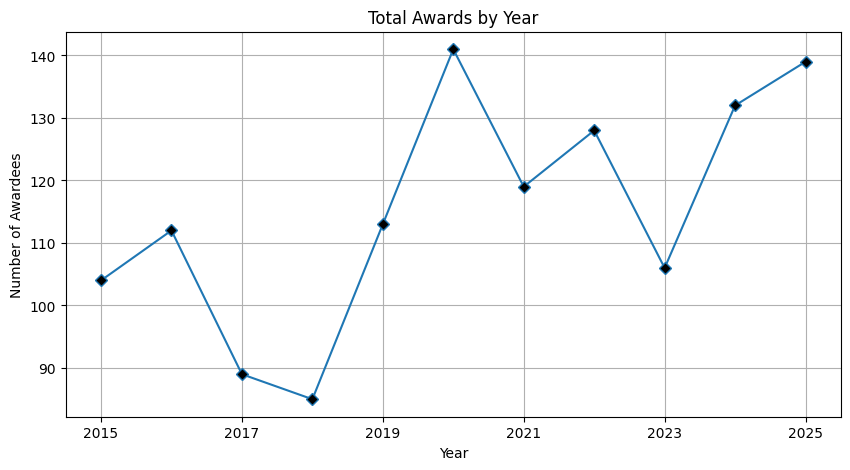

In [ ]:
#@title 1) What are the Total Awards by Year?

# Grouping by Year and Count Awards
awards_by_year = padmaawards_df.groupby('Year')['Category'].count()

# Plotting a line graph
awards_by_year.plot(x='Year', y='Num of Awards', kind='line', marker='D',
markerfacecolor='black', markersize=6, figsize=(10, 5))
plt.title('Total Awards by Year')
plt.xlabel('Year')
plt.ylabel('Number of Awardees')
plt.grid(True)
plt.show()


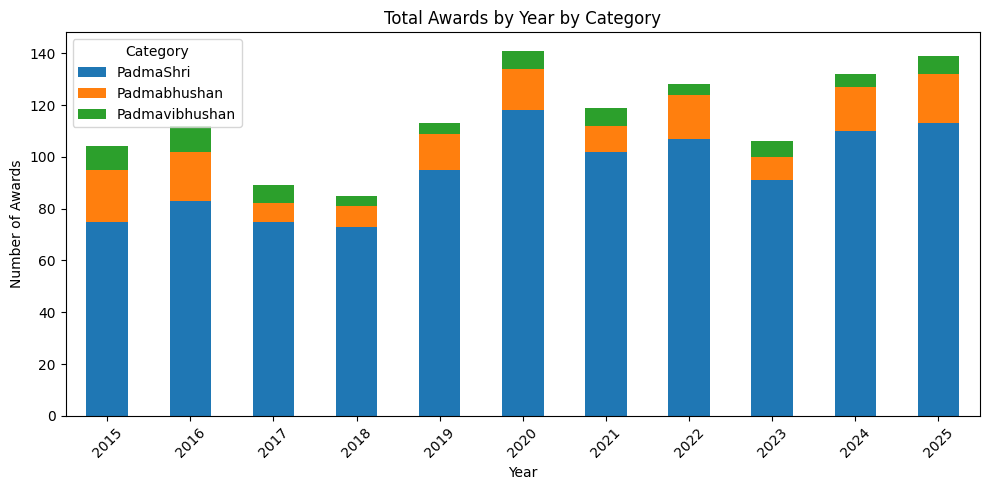

In [ ]:
#@title 2) What are the total Awards by Year & what are their Award Types?

# Creating a cross-tabulation of Year and Category, counting occurrences
awards_by_year_category = pd.crosstab(padmaawards_df['Year'],
                                      padmaawards_df['Category'])

# Plotting the stacked bar chart
awards_by_year_category.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Total Awards by Year by Category')
plt.xlabel('Year')
plt.ylabel('Number of Awards')
plt.legend(title='Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


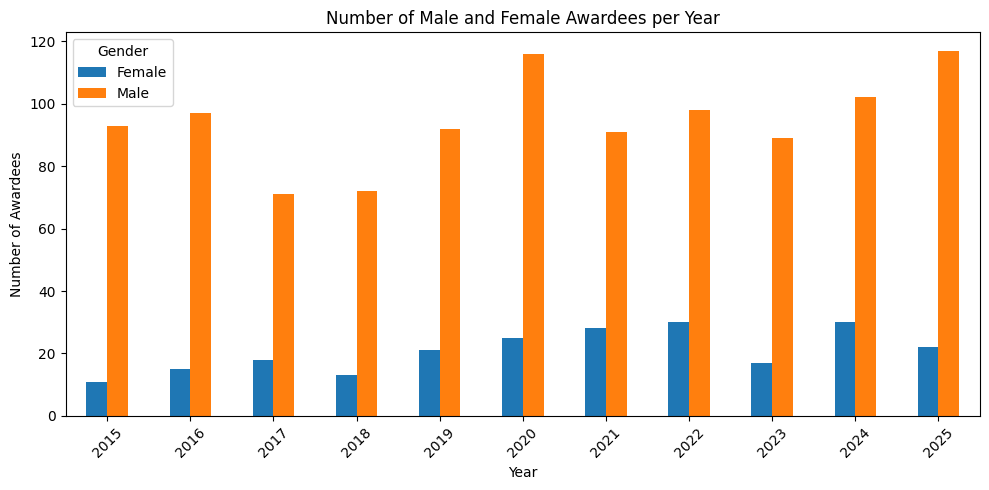

In [ ]:
#@title 3) How many male and female awardees by year?

# Creating a new coloumn with the Gender of the awardees
padmaawards_df['Gender'] = np.where(
    padmaawards_df['Name'].str.contains("Smt|Ms.", na=False, regex=True),
    'Female', 'Male')

# Creating a cross-tabulation of Year and Gender, counting occurrences
gender_by_year = pd.crosstab(padmaawards_df['Year'], padmaawards_df['Gender'])

# Plotting the bar chart
gender_by_year.plot(kind='bar', figsize=(10, 5))
plt.title('Number of Male and Female Awardees per Year')
plt.xlabel('Year')
plt.ylabel('Number of Awardees')
plt.legend(title='Gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


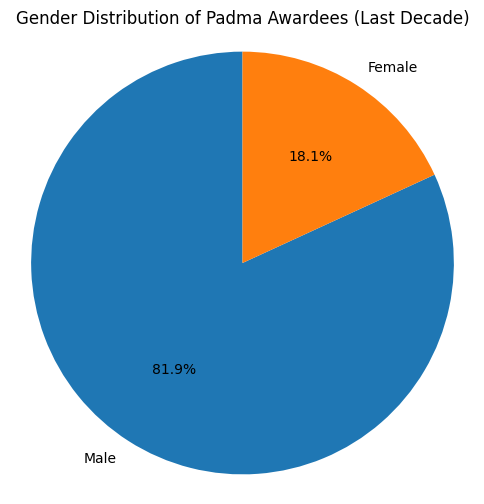

In [ ]:
#@title 3.1) Total distribution of male and female awardees

# Calculating the total number of male and female awardees
gender_counts_last_decade = padmaawards_df['Gender'].value_counts()

# Creating the pie chart
plt.figure(figsize=(6, 6))
plt.pie(gender_counts_last_decade, labels=gender_counts_last_decade.index,
        autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution of Padma Awardees (Last Decade)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

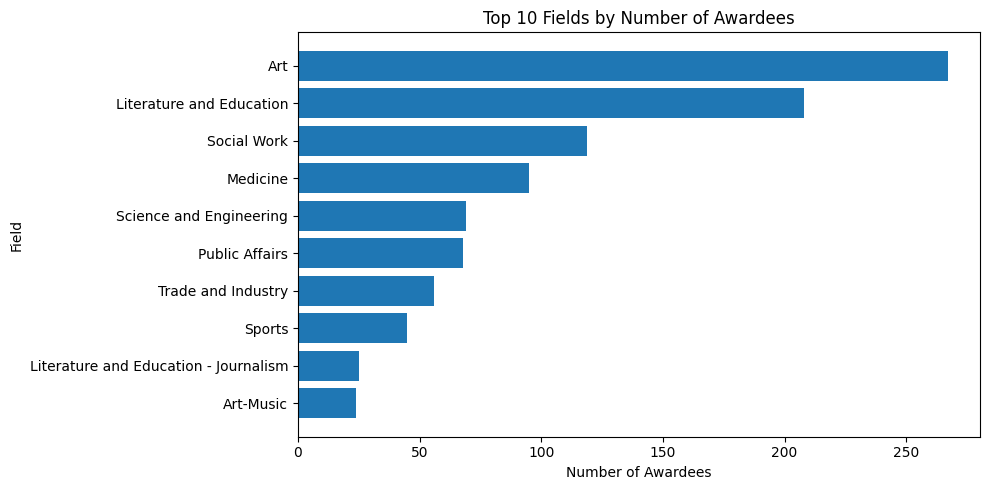

In [ ]:
#@title 4) Which are the top 10 fields with the most number of awardees?

# Cleaning the 'Field' column
padmaawards_df['Field'] = padmaawards_df['Field'].apply(lambda x: re.sub('&', 'and', str(x)))

# Counting the top 10 fields
field_counts = padmaawards_df['Field'].value_counts()
top_10_fields = field_counts.head(10)

# Creating the horizontal bar graph
plt.figure(figsize=(10, 5))
plt.barh(top_10_fields.index, top_10_fields.values)
plt.xlabel('Number of Awardees')
plt.ylabel('Field')
plt.title('Top 10 Fields by Number of Awardees')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


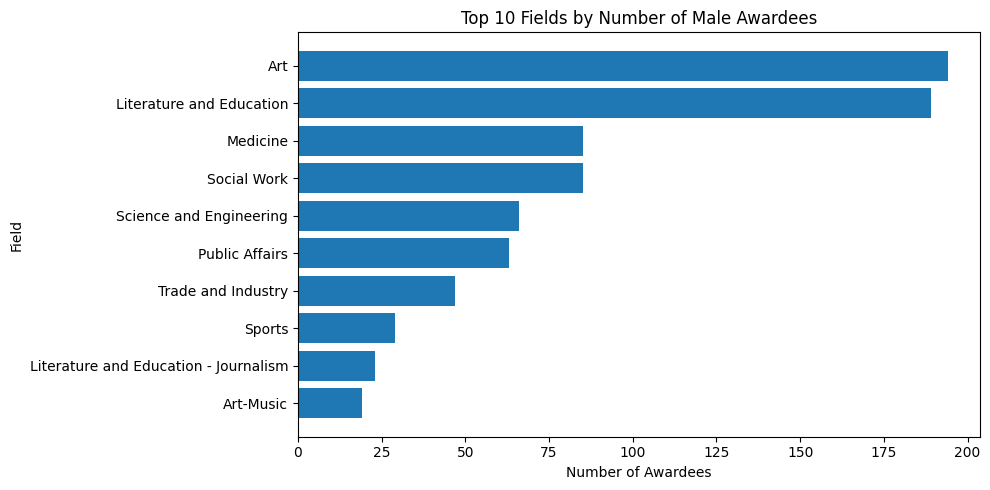

In [ ]:
#@title 5) Which are the top 10 fields with the most number of male awardees?

# Filtering the DataFrame to include only male awardees
male_awardees_df = padmaawards_df[padmaawards_df['Gender'] == 'Male']

# Calculating the number of male awardees for each field
field_counts_male = male_awardees_df['Field'].value_counts()

# Getting the top 10 fields for male awardees
top_10_fields_male = field_counts_male.head(10)

# Creating the horizontal bar graph
plt.figure(figsize=(10, 5))
plt.barh(top_10_fields_male.index, top_10_fields_male.values)
plt.xlabel('Number of Awardees')
plt.ylabel('Field')
plt.title('Top 10 Fields by Number of Male Awardees')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


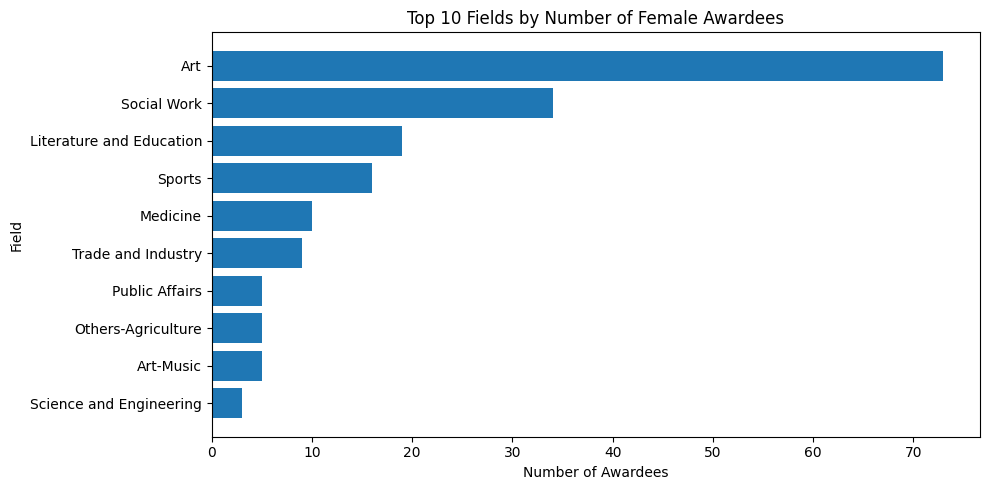

In [ ]:
#@title 6) Which are the top 10 fields with the most number of female awardees?

# Filtering the DataFrame to include only female awardees
female_awardees_df = padmaawards_df[padmaawards_df['Gender'] == 'Female']

# Calculating the number of female awardees for each field
field_counts_female = female_awardees_df['Field'].value_counts()

# Getting the top 10 fields for female awardees
top_10_fields_female = field_counts_female.head(10)

# Creating the horizontal bar graph
plt.figure(figsize=(10, 5))
plt.barh(top_10_fields_female.index, top_10_fields_female.values)
plt.xlabel('Number of Awardees')
plt.ylabel('Field')
plt.title('Top 10 Fields by Number of Female Awardees')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


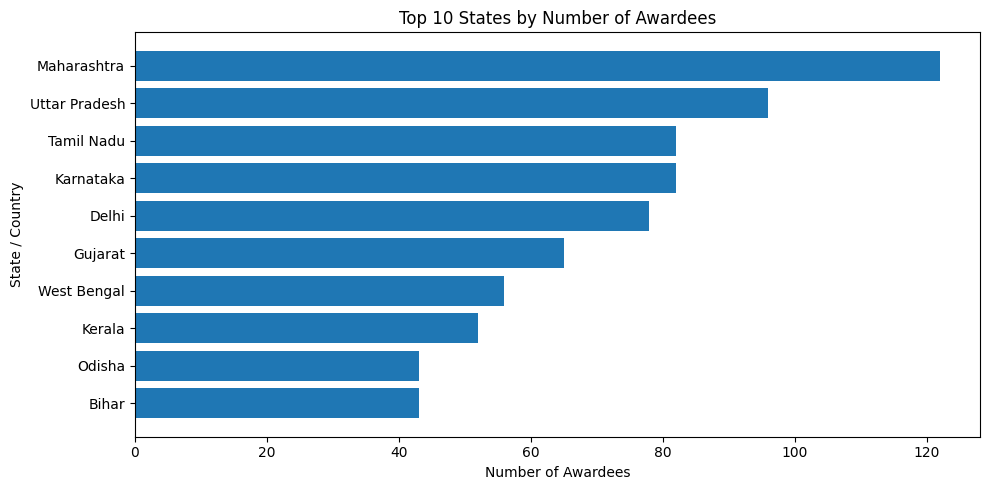

In [ ]:
#@title 7) Which are the top 10 states with the most number of awardees?

# Counting the top 10 states
state_counts = padmaawards_df['State / Country'].value_counts()
top_10_fields = state_counts.head(10)

# Creating the horizontal bar graph
plt.figure(figsize=(10, 5))
plt.barh(top_10_fields.index, top_10_fields.values)
plt.xlabel('Number of Awardees')
plt.ylabel('State / Country')
plt.title('Top 10 States by Number of Awardees')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


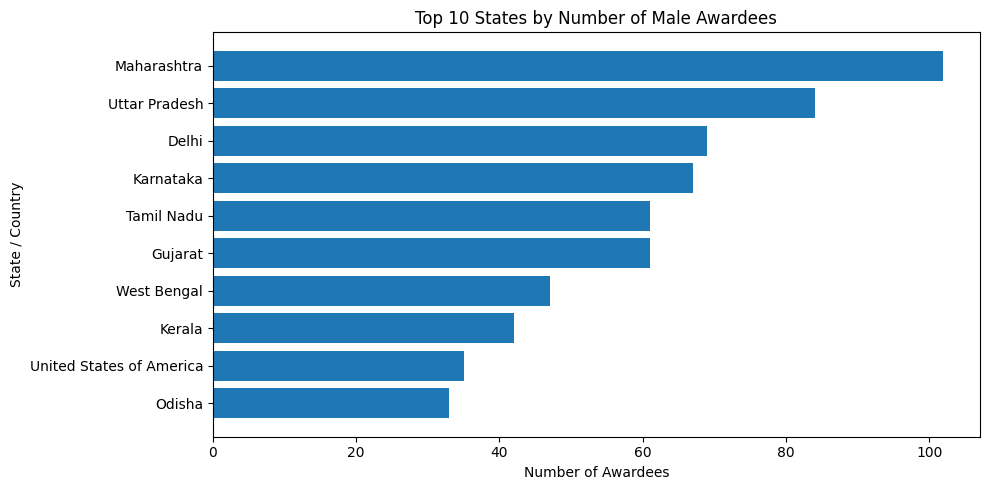

In [ ]:
#@title 8) Which are the top 10 States with the most number of male awardees?

# Filtering the DataFrame to include only male awardees
male_awardees_df = padmaawards_df[padmaawards_df['Gender'] == 'Male']

# Calculating the number of male awardees for each state
state_counts_male = male_awardees_df['State / Country'].value_counts()

# Getting the top 10 states for male awardees
top_10_states_male = state_counts_male.head(10)

# Creating the horizontal bar graph
plt.figure(figsize=(10, 5))
plt.barh(top_10_states_male.index, top_10_states_male.values)
plt.xlabel('Number of Awardees')
plt.ylabel('State / Country')
plt.title('Top 10 States by Number of Male Awardees')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
